# Conditional Workflow 

In [42]:
from langgraph.graph import StateGraph , START , END 
from typing  import TypedDict , Literal 

### Schema 

In [43]:
class Quadstate(TypedDict):
    a : int 
    b : int 
    c : int 

    equation : str 
    discriminant : str 

    result :    str 

### Define Graph 

In [44]:
graph = StateGraph(Quadstate)

#### Functions 

1. Show Equation 

In [45]:
def show_equation(state:Quadstate):
    equation = f"({state['a']}x^2) + ({state['b']}x) + ({state['c']}) = 0"
    return {"equation" : equation}

2. Calculate Discriminant

In [46]:
def cal_Discriminant(state:Quadstate):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {"discriminant" : discriminant}

In [47]:
def real_root(state:Quadstate):
    pass
def same_real_root(state:Quadstate):
    pass
def not_real_root(state:Quadstate):
    pass

#### Nodes 

In [48]:
graph.add_node("show_equation" , show_equation)
graph.add_node("cal_Discriminant" , cal_Discriminant)
graph.add_node("real_root" , real_root)
graph.add_node("same_real_root" , same_real_root)
graph.add_node("not_real_root" , not_real_root)



### Edges

In [49]:
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation" , "cal_Discriminant")
graph.add_edge("cal_Discriminant",END)

workflow = graph.compile()


In [50]:
if __name__ == "__main__":
    initial_state = {
        "a" : 1,
        "b" : -3,
        "c" : 2
    }
    result = workflow.invoke(initial_state)
    print(result)

{'a': 1, 'b': -3, 'c': 2, 'equation': '(1x^2) + (-3x) + (2) = 0', 'discriminant': 1}


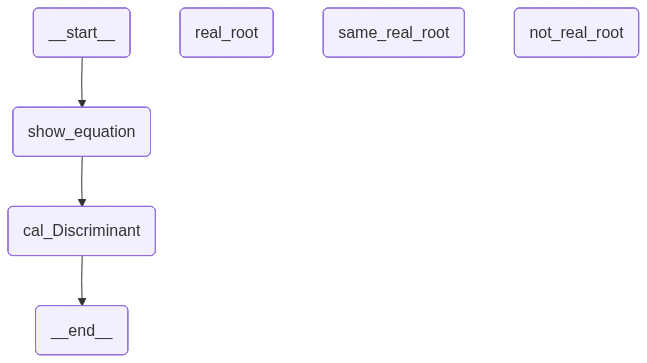

In [51]:
workflow